In [1]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader,ConcatDataset,TensorDataset
from torch.utils.data.sampler import WeightedRandomSampler
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score,classification_report
import numpy as np
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
from ekyn import *
from sklearn.model_selection import train_test_split

class ResidualBlock(nn.Module):
    def __init__(self,in_channels,out_channels,*args, **kwargs):
        super().__init__(*args, **kwargs)
        self.c1 = nn.Conv1d(in_channels=in_channels,out_channels=out_channels,kernel_size=3,padding='same')
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.c2 = nn.Conv1d(in_channels=out_channels,out_channels=out_channels,kernel_size=3,padding='same')
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.c3 = nn.Conv1d(in_channels=out_channels,out_channels=out_channels,kernel_size=3,padding='same')
        self.c4 = nn.Conv1d(in_channels=out_channels,out_channels=out_channels,kernel_size=3,padding='same')
        self.mp = nn.MaxPool1d(kernel_size=2)
    def forward(self,x):
        identity = x
        x = self.c1(x)
        x = self.bn1(x)
        x = nn.functional.relu(x)
        x = self.c2(x)
        x = self.bn2(x)
        x = nn.functional.relu(x)
        x = self.c3(x)
        x = nn.functional.relu(x)
        x = self.c4(x)
        x = x + identity
        x = nn.functional.relu(x)
        x = self.mp(x)
        return x

class SleepStageEncoder(nn.Module):
    def __init__(self, d_embedding, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.blocks = nn.Sequential(*[ResidualBlock(in_channels=1,out_channels=d_embedding)]+[ResidualBlock(in_channels=d_embedding,out_channels=d_embedding) for i in range(3)])
        self.gap = nn.AdaptiveAvgPool1d(output_size=1)
        self.classifier = nn.Linear(in_features=d_embedding,out_features=3)
    def forward(self,x):
        x = self.blocks(x)
        x = self.gap(x)
        x = x.flatten(1,2)
        x = self.classifier(x)
        return x

def get_dataloaders(train_ids,test_ids,path_to_dataset,batch_size=32,weighted=False):
    if weighted:
        dataset = ConcatDataset([TensorDataset(*torch.load(f'{path_to_dataset}/{id}_{condition}.pt',weights_only=False)) for id in train_ids for condition in ['PF','Vehicle']])
        labels = torch.tensor([data[1].argmax().item() for data in dataset])
        class_counts = torch.bincount(labels)
        class_weights = 1. / class_counts.float()
        weights = class_weights[labels]
        trainloader = DataLoader(dataset, batch_size=batch_size, sampler=WeightedRandomSampler(weights, num_samples=len(weights), replacement=True))

        dataset = ConcatDataset([TensorDataset(*torch.load(f'{path_to_dataset}/{id}_{condition}.pt',weights_only=False)) for id in test_ids for condition in ['PF','Vehicle']])
        labels = torch.tensor([data[1].argmax().item() for data in dataset])
        class_counts = torch.bincount(labels)
        class_weights = 1. / class_counts.float()
        weights = class_weights[labels]
        testloader = DataLoader(dataset, batch_size=batch_size, sampler=WeightedRandomSampler(weights, num_samples=len(weights), replacement=True))
    else:
        trainloader = DataLoader(ConcatDataset([TensorDataset(*torch.load(f'{path_to_dataset}/{id}_{condition}.pt',weights_only=False)) for id in train_ids for condition in ['Vehicle','PF']]),batch_size=batch_size,shuffle=True)
        testloader = DataLoader(ConcatDataset([TensorDataset(*torch.load(f'{path_to_dataset}/{id}_{condition}.pt',weights_only=False)) for id in test_ids for condition in ['Vehicle','PF']]),batch_size=batch_size,shuffle=True)
    return trainloader,testloader

path_to_experiments = f'../prototypes'
path_to_dataset = f'../pt_ekyn_robust_50hz'

train_ids,test_ids = train_test_split(ekyn_ids(),random_state=0)
print(train_ids,test_ids)

['F1-0', 'B3-1', 'A4-0', 'F1-1', 'E2-1', 'C4-1', 'F5-1', 'E4-0', 'B1-0', 'A1-0', 'C1-0', 'E4-1'] ['A1-1', 'C4-0', 'D1-0', 'E1-0']


In [2]:
encoder = SleepStageEncoder(d_embedding=32)
trainloader,testloader = get_dataloaders(train_ids,test_ids,path_to_dataset,batch_size=512,weighted=True)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(encoder.parameters(), lr=3e-4)

In [3]:
config = {
    'device':f'cuda',
    'train_ids':train_ids,
    'test_ids':test_ids,
    'trainlossi':[],
    'testlossi':[],
    'trainf1i':[],
    'testf1i':[],
    'trainf1p':[],
    'testf1p':[],
    'trainf1s':[],
    'testf1s':[],
    'trainf1w':[],
    'testf1w':[],
    'best_dev_loss':float('inf'),
    'best_dev_loss_epoch':0,
    'best_dev_f1':0,
    'best_dev_f1_epoch':0,
    'validation_frequency_epochs':1
}

encoder.to(config["device"])

lossi = []
best_ma_loss = float('inf')
window_size = 10
pbar = tqdm(range(200))
for epoch in pbar:
    for Xi,yi in trainloader:
        Xi, yi = Xi.to(config["device"]), yi.to(config["device"])
        logits = encoder(Xi)
        loss = criterion(logits, yi)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lossi.append(loss.item())

    window_size = 10
    plt.plot(lossi)
    ma_loss = moving_average(lossi, window_size)
    plt.plot(range(window_size-1, len(lossi)),ma_loss) 
    plt.savefig('loss.jpg')
    plt.close()

    if ma_loss[-1] < best_ma_loss:
        best_ma_loss = ma_loss[-1]

    pbar.set_description(f'{best_ma_loss:.3f}')

# .230

0.302:   2%|▏         | 4/200 [00:26<21:22,  6.54s/it]


KeyboardInterrupt: 

In [6]:
torch.save(encoder.state_dict(),f'encoder.pt')

0.29390668869018555
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     69276
           1       0.93      0.91      0.92     69089
           2       0.86      0.83      0.84     68995

    accuracy                           0.89    207360
   macro avg       0.89      0.89      0.89    207360
weighted avg       0.89      0.89      0.89    207360



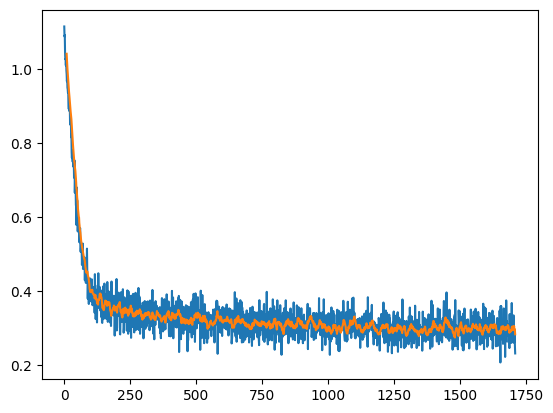

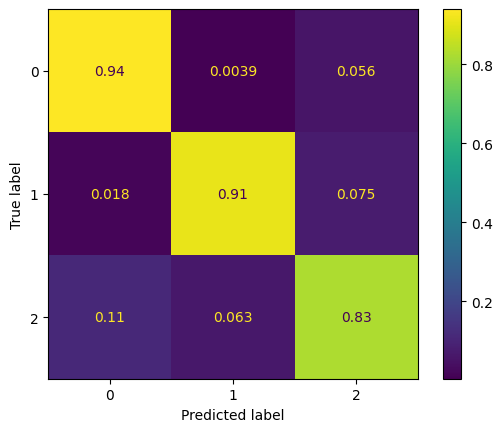

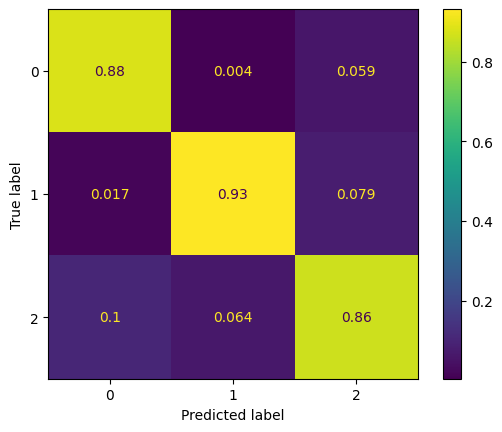

In [5]:
window_size = 10
plt.plot(lossi)
plt.plot(range(window_size-1, len(lossi)), moving_average(lossi, window_size))

with torch.no_grad():
    p = torch.vstack([torch.hstack([encoder(Xi.to(config["device"])),yi.to(config["device"])]) for Xi,yi in trainloader]).cpu()
    p = torch.hstack([p,p[:,:3].softmax(dim=1).argmax(axis=1).unsqueeze(1)])
    logits = p[:,:3]
    y_true = p[:,3:6].argmax(axis=1)
    y_pred = p[:,6:]
    f1 = f1_score(y_true,y_pred,average='macro')
    loss = criterion(logits,y_true).item()
    report = classification_report(y_pred=y_pred,y_true=y_true)
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize='true')
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize='pred')
print(loss)
print(report)

In [ ]:
config = {
    'device':f'cuda',
    'train_ids':train_ids,
    'test_ids':test_ids,
    'trainlossi':[],
    'testlossi':[],
    'trainf1i':[],
    'testf1i':[],
    'trainf1p':[],
    'testf1p':[],
    'trainf1s':[],
    'testf1s':[],
    'trainf1w':[],
    'testf1w':[],
    'best_dev_loss':float('inf'),
    'best_dev_loss_epoch':0,
    'best_dev_f1':0,
    'best_dev_f1_epoch':0,
    'validation_frequency_epochs':1
}

encoder.to(config["device"])

lossi = []
best_ma_loss = float('inf')
window_size = 10
pbar = tqdm(range(200))

for epoch in pbar:
    for Xi, yi in trainloader:
        Xi, yi = Xi.to(config["device"]), yi.to(config["device"])
        logits = encoder(Xi)
        loss = criterion(logits, yi)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lossi.append(loss.item())

    ma_loss = moving_average(lossi, window_size)

    if ma_loss[-1] < best_ma_loss:
        best_ma_loss = ma_loss[-1]

    pbar.set_description(f'{best_ma_loss:.3f}')

    if epoch % config["validation_frequency_epochs"] == 0:
        loss, f1, report = evaluate(trainloader, encoder, criterion, config["device"])
        config["trainlossi"].append(loss)
        config["trainf1i"].append(report['macro avg']['f1-score'])
        config["trainf1p"].append(report['0']['f1-score'])
        config["trainf1s"].append(report['1']['f1-score'])
        config["trainf1w"].append(report['2']['f1-score'])
        
        loss, f1, report = evaluate(testloader, encoder, criterion, config["device"])
        config["testlossi"].append(loss)
        config["testf1i"].append(report['macro avg']['f1-score'])
        config["testf1p"].append(report['0']['f1-score'])
        config["testf1s"].append(report['1']['f1-score'])
        config["testf1w"].append(report['2']['f1-score'])
        update_plot(epoch, config, loss_offset=0,  window_size=window_size)
        plt.savefig(f'loss.jpg')
        plt.close()

        if config["testlossi"][-1] < config["best_dev_loss"]:
            config["best_dev_loss"] = config["testlossi"][-1]
            config["best_dev_loss_epoch"] = epoch // config["validation_frequency_epochs"]
        if config["testf1i"][-1] > config["best_dev_f1"]:
            config["best_dev_f1"] = config["testf1i"][-1]
            config["best_dev_f1_epoch"] = epoch // config["validation_frequency_epochs"]
